In [1]:
# Imports (/Load Libraries?)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

# COL == Cost of Living
# CC == Country Codes, we need this to link df_diet and df_COL since df_COL doesnt have a country code column.

df_diet = pd.read_csv("price_of_healthy_diet_clean.csv")
df_COL = pd.read_csv("Cost of living index by country 2020.csv")
df_CC = pd.read_csv("country_codes_cleaned.csv")

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Question 1: Are some countries disadvantaged in maintaining quality health?

> Strategy here is to get the overall cost of living in a country in 2023 with the healthy diet. The dataset avaibale for this is in USD. Then compare the total cost of healthy diet with the available data for income in the same year, this turns out to be GNI (Gross National Income) in PPP $. Since we can't directly algebraically add or subtract these two features due to their unit difference, their ratio will be the determinant. This ratio will be called afforability. It is the ratio of the GNI to overall healthy diet cost. The higher this number, the affordable it is for that country in 2023 to have a healthy diet while maintaining other costs of living constant.

In [3]:
# Consider only the year 2023
df_diet_2023 = df_diet[df_diet["year"] == 2023]
df_diet_2023.shape
print(df_diet_2023.columns)

# Add other cost of living expenses
df_CC_other = df_CC[['name', 'country-code']]

  # Add country code in df_COL
df_merged = pd.merge(df_COL, df_CC_other, left_on="Country", right_on="name", how='outer')

  # Remove blanks in df_merged
df_merged = df_merged[df_merged["Country"].notna()]

  # Merge df_merged and df_diet_2020
df_merged_diet = pd.merge(df_merged, df_diet_2023, left_on="country-code", right_on="country_code", how='outer')

  # Remove blanks in df_merged_diet
df_merged_diet_nadropped = df_merged_diet.dropna(subset=["country-code", "country_code"])

  # Keep only the necessary columns
df_merged_diet_nadropped = df_merged_diet_nadropped[["Country", "Cost of Living Index", "Rent Index", "Cost of Living Plus Rent Index", "Groceries Index", "Local Purchasing Power Index", "country_code", "cost_healthy_diet_ppp_usd", "annual_cost_healthy_diet_usd", "cost_category"]]

  # Export
df_merged_diet_nadropped.to_csv("merged_diet_nadropped.csv", index=False)

df_merged_diet_nadropped



Index(['country_code', 'country', 'region', 'year',
       'cost_healthy_diet_ppp_usd', 'annual_cost_healthy_diet_usd',
       'cost_vegetables_ppp_usd', 'cost_fruits_ppp_usd',
       'total_food_components_cost', 'cost_category', 'data_quality'],
      dtype='object')


,Country,Cost of Living Index,Rent Index,Cost of Living Plus Rent Index,Groceries Index,Local Purchasing Power Index,country_code,cost_healthy_diet_ppp_usd,annual_cost_healthy_diet_usd,cost_category
1,Albania,36.39,8.55,23.07,28.39,29.56,8.0,4.58,1671.70,High Cost
2,Algeria,30.10,5.34,18.26,30.71,28.69,12.0,5.41,1974.65,High Cost
5,Azerbaijan,29.92,9.48,20.15,23.74,30.20,31.0,4.13,1507.45,High Cost
7,Australia,73.54,34.86,55.04,67.23,107.31,36.0,3.10,1131.50,Medium Cost
8,Austria,70.38,26.81,49.54,61.73,82.38,40.0,2.91,1062.15,Medium Cost
...,...,...,...,...,...,...,...,...,...,...
177,Tanzania,35.25,14.04,25.11,29.66,17.58,834.0,3.32,1211.80,Medium Cost
178,United States,71.05,40.32,56.36,66.61,109.52,840.0,2.76,1007.40,Medium Cost
180,Uruguay,51.04,14.43,33.53,40.12,37.46,858.0,4.29,1565.85,High Cost
181,Uzbekistan,26.01,7.54,17.18,21.59,24.31,860.0,4.78,1744.70,High Cost


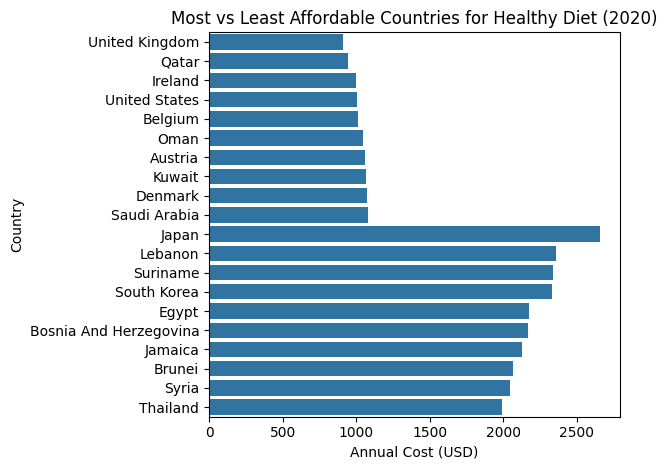

In [4]:
# Top 10 most vs least affordable countries
top_bottom = pd.concat([
    df_merged_diet_nadropped.nsmallest(10, 'annual_cost_healthy_diet_usd'),
    df_merged_diet_nadropped.nlargest(10, 'annual_cost_healthy_diet_usd')
])
sns.barplot(data=top_bottom, x='annual_cost_healthy_diet_usd', y='Country')
plt.title('Most vs Least Affordable Countries for Healthy Diet (2020)')
plt.xlabel('Annual Cost (USD)')
plt.tight_layout()
plt.show()

In [5]:
import pandas as pd

df_food_expenditure = pd.read_csv("food-expenditure-share-gdp.csv")
df_healthy_diet = pd.read_csv("price_of_healthy_diet_clean.csv")

# Only Consider 2023 as this is the latest data in both datasets
df_food_expenditure = df_food_expenditure[df_food_expenditure["Year"] == 2023]
df_healthy_diet = df_healthy_diet[df_healthy_diet["year"] == 2023]

# Only Consider Relevant Columns in each dataset
df_food_expenditure_2023 = df_food_expenditure[["Entity", "Code", "Food expenditure", "Total consumer expenditure"]]
df_healthy_diet_2023 = df_healthy_diet[["country_code", "country", "annual_cost_healthy_diet_usd"]]

# Connect the two dataset using a country code df.
df_country_code = pd.read_csv("country_codes_cleaned.csv")
df_country_code = df_country_code[["name", "alpha-3", "country-code"]]
df_merged_1 = pd.merge(df_food_expenditure_2023, df_country_code, left_on="Code", right_on="alpha-3", how='outer')
df_merged_all = pd.merge(df_merged_1, df_healthy_diet_2023, left_on="country-code", right_on="country_code", how='outer')

# Drop na
df_merged_all = df_merged_all.dropna()

# Subtract the food expenditure to total consumer expenditure and add the healthy diet cost, this new feature is names "Total consumer expenditure w healthy diet"
df_merged_all["Total consumer expenditure w healthy diet"] = (df_merged_all["Total consumer expenditure"] * (1 - (df_merged_all["Food expenditure"]/100))) + df_merged_all["annual_cost_healthy_diet_usd"]

# Merge Data for GNI (Gross National Income) in PPP from World Bank Group
df_GNI_PPP = pd.read_csv("GNI PPP.csv")
print(df_GNI_PPP.columns)
df_merged_all = pd.merge(df_merged_all, df_GNI_PPP, left_on="Code", right_on="Country Code", how='outer')

# Add Affordability Feature. Affordability = GNI (PPP) / Total consumer expenditure with healthy diet (USD)
df_merged_all["Affordability"] = df_merged_all["2023"] / df_merged_all["Total consumer expenditure w healthy diet"]

# Drop na
df_merged_all = df_merged_all.dropna()

# Determine Affordable and not affordable. Since this is a threshold to accurately determine, use a Data-driven threshold.
# Let top 25% quantile be not affordable, bottom 25% be affordable and everything in between to be moderate.
quantile_25 = df_merged_all["Affordability"].quantile(0.25)
quantile_75 = df_merged_all["Affordability"].quantile(0.75)
df_merged_all['Cost Category'] = pd.cut(df_merged_all['Affordability'], bins=[0, quantile_25, quantile_75, float('inf')], labels=['Not Affordable', 'Moderate', 'Affordable'])

# Export
df_merged_all.to_csv("merged_all.csv", index=False)

# Data visualization is done in Data Wrapper:
# https://datawrapper.dwcdn.net/oXEqQ/1/

Index(['Country Code', '2023'], dtype='object')


Question 2: Do the countries that can afford to eat healthy have higher mortality rates? If not, why might that be?

['Country', 'Health Care Index', 'Health Care Exp. Index']
       Country  Health Care Index  Health Care Exp. Index
0       Taiwan              86.71                  159.66
1  South Korea              81.97                  149.94
2        Japan              81.14                  148.24
3      Denmark              80.00                  147.47
4       France              79.99                  146.81
 


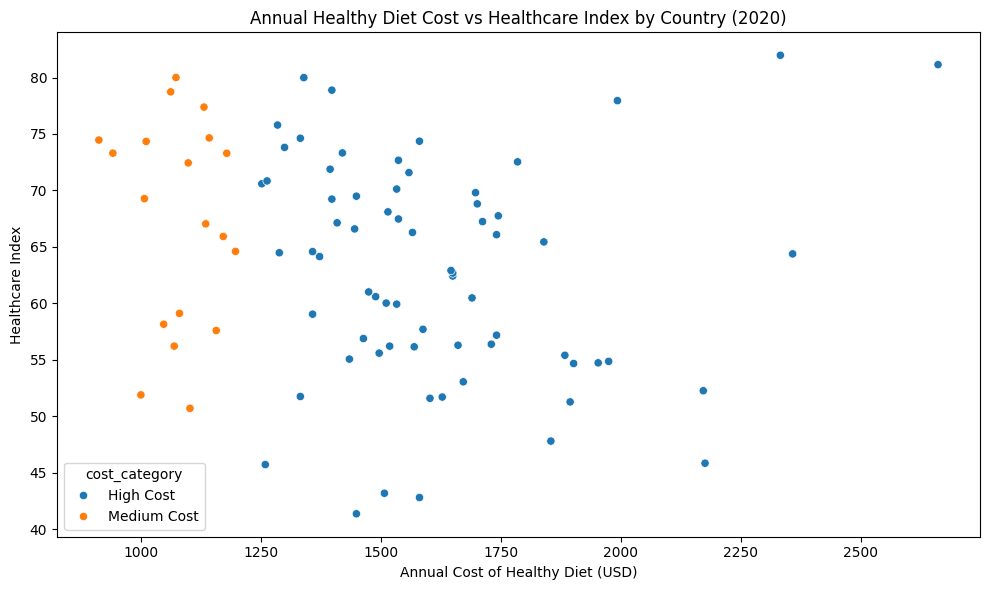

 
Correlation: -0.155


In [6]:
# Load the healthcare index data
df_health = pd.read_csv("Health care index by countries 2020.csv")

# Preview to confirm column names
print(df_health.columns.tolist())
print(df_health.head())

print(" ")

# Merge with Q1's output which already has diet affordability data
df_q2 = pd.merge(df_merged_diet_nadropped, df_health, on="Country", how="inner")

# Scatter plot giving information on healthy diet cost vs healthcare index
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_q2,
    x='annual_cost_healthy_diet_usd',
    y='Health Care Index',  # update this to match actual column name
    hue='cost_category'
)
plt.title('Annual Healthy Diet Cost vs Healthcare Index by Country (2020)')
plt.xlabel('Annual Cost of Healthy Diet (USD)')
plt.ylabel('Healthcare Index')
plt.tight_layout()
plt.show()

# Correlation value
corr = df_q2['annual_cost_healthy_diet_usd'].corr(df_q2['Health Care Index'])
print(" ")
print(f"Correlation: {corr:.3f}")

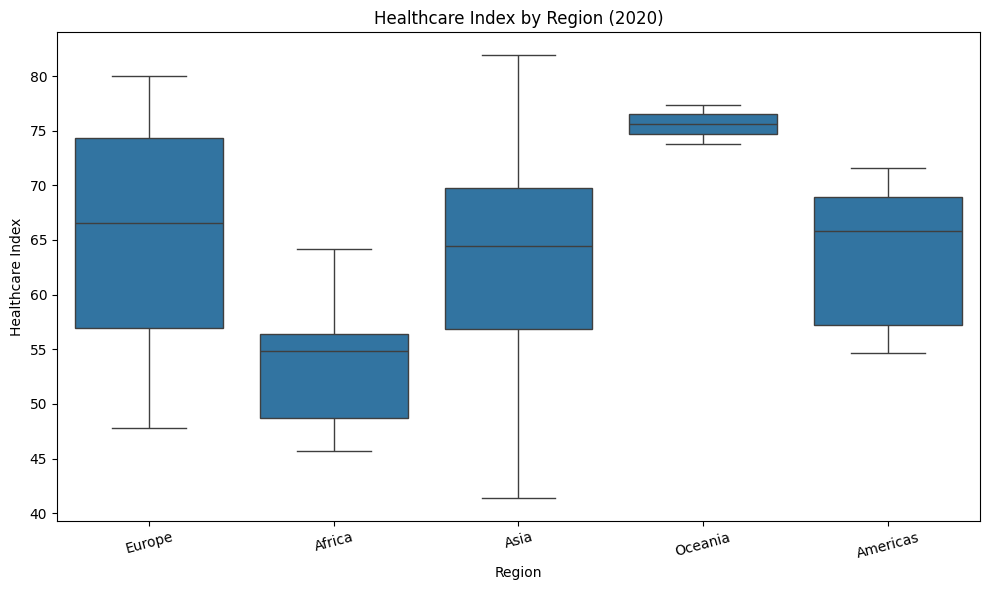

In [7]:
# Add region info via df_CC
df_q2_region = pd.merge(df_q2, df_CC[['name', 'region']], left_on='Country', right_on='name', how='left')

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_q2_region, x='region', y='Health Care Index')
plt.title('Healthcare Index by Region (2020)')
plt.xlabel('Region')
plt.ylabel('Healthcare Index')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

Question 3: How has the cost of healthy food changed between 2020 to 2022 (how were different countries affected by things like Covid and etc.)?

(172, 13)
['country_code', 'country_2020', 'cost_healthy_diet_ppp_usd_2020', 'annual_cost_healthy_diet_usd_2020', 'cost_category_2020', 'country_2022', 'cost_healthy_diet_ppp_usd_2022', 'annual_cost_healthy_diet_usd_2022', 'cost_category_2022', 'alpha-3', 'region', 'daily_price_change', 'yearly_price_change']
<bound method NDFrame.head of      country_code              country_2020  cost_healthy_diet_ppp_usd_2020  \
0               8                   Albania                            3.40   
1              12                   Algeria                            4.19   
2              24                    Angola                            3.70   
3              28       Antigua and Barbuda                            4.67   
4              51                   Armenia                            3.54   
..            ...                       ...                             ...   
167           840  United States of America                            2.28   
168           858          

/tmp/ipykernel_2536/2405576931.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'${t:.2f}' for t in ax.get_xticks()])


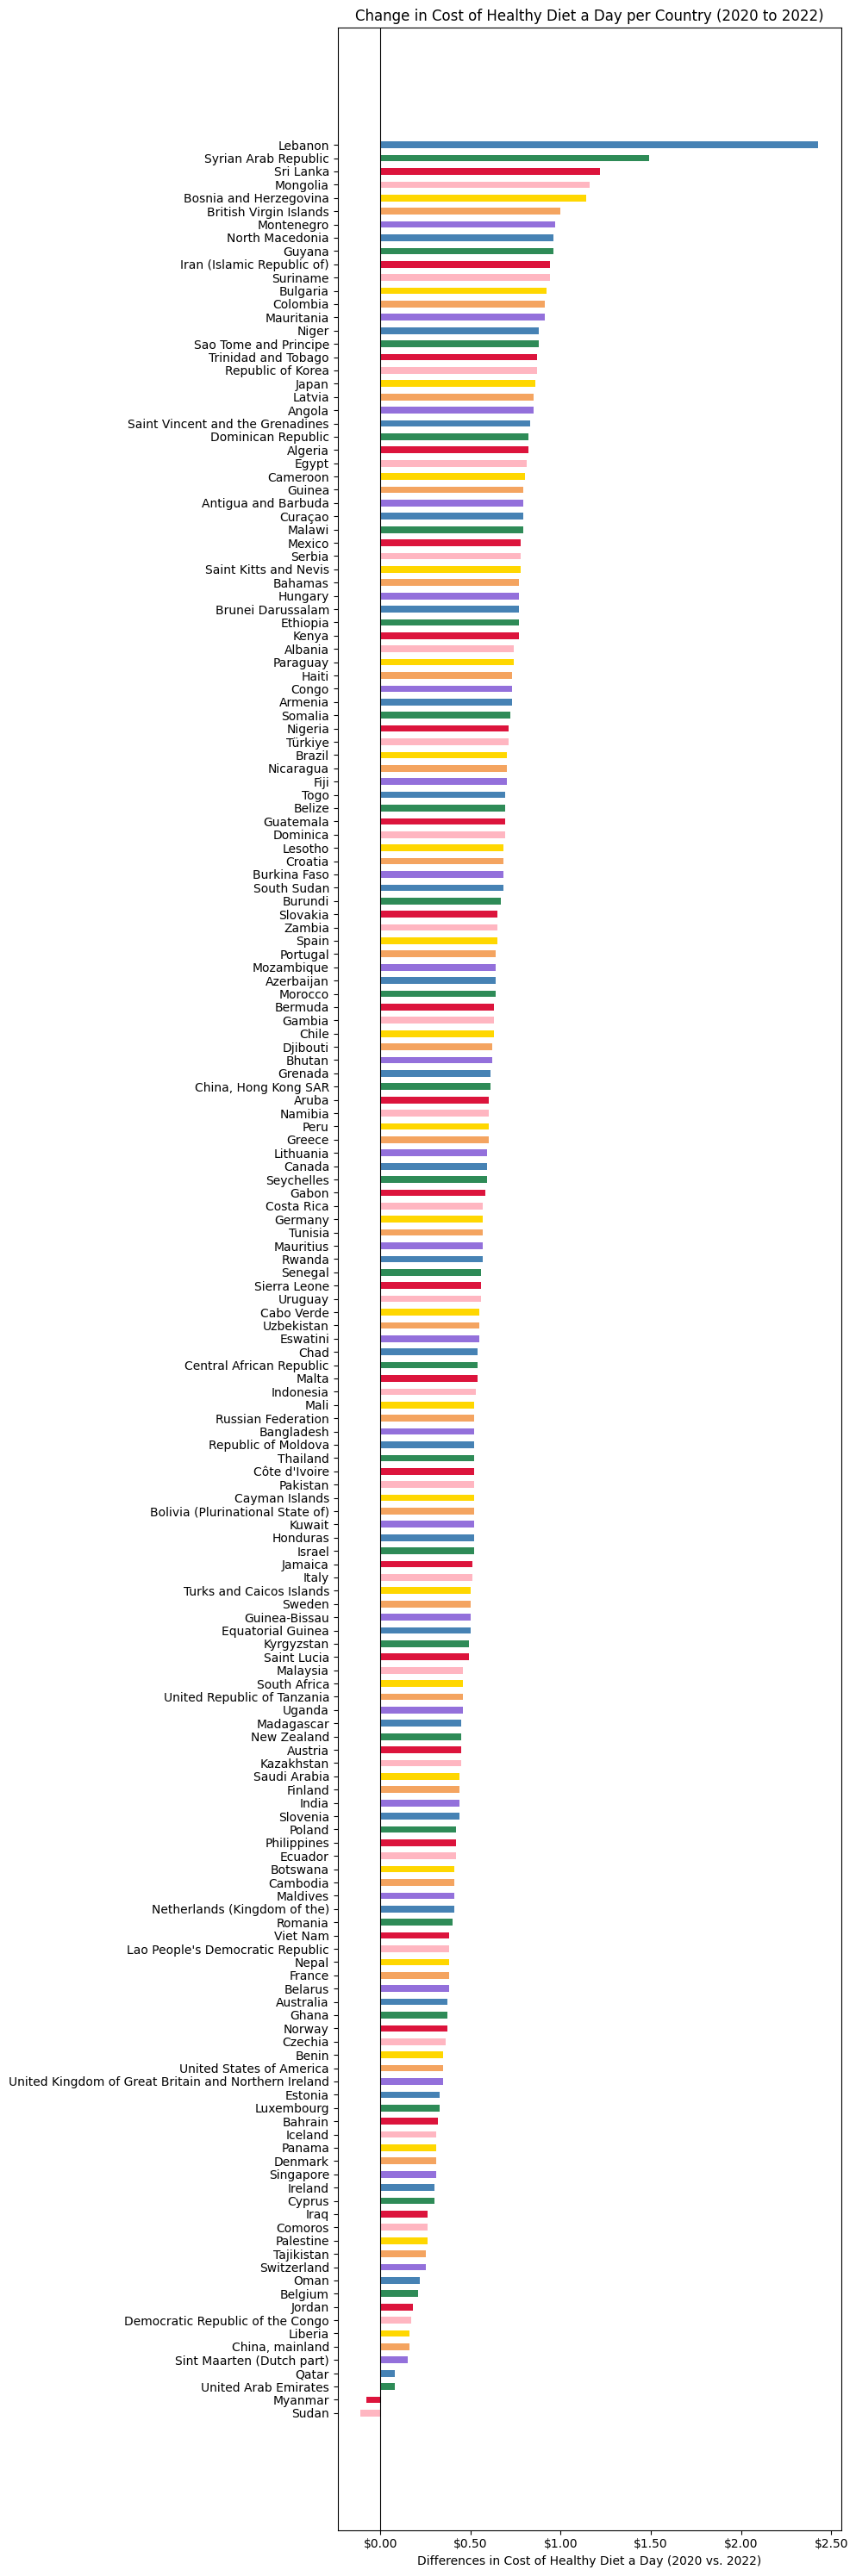

/tmp/ipykernel_2536/2405576931.py:76: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'${t:.2f}' for t in ax.get_xticks()])


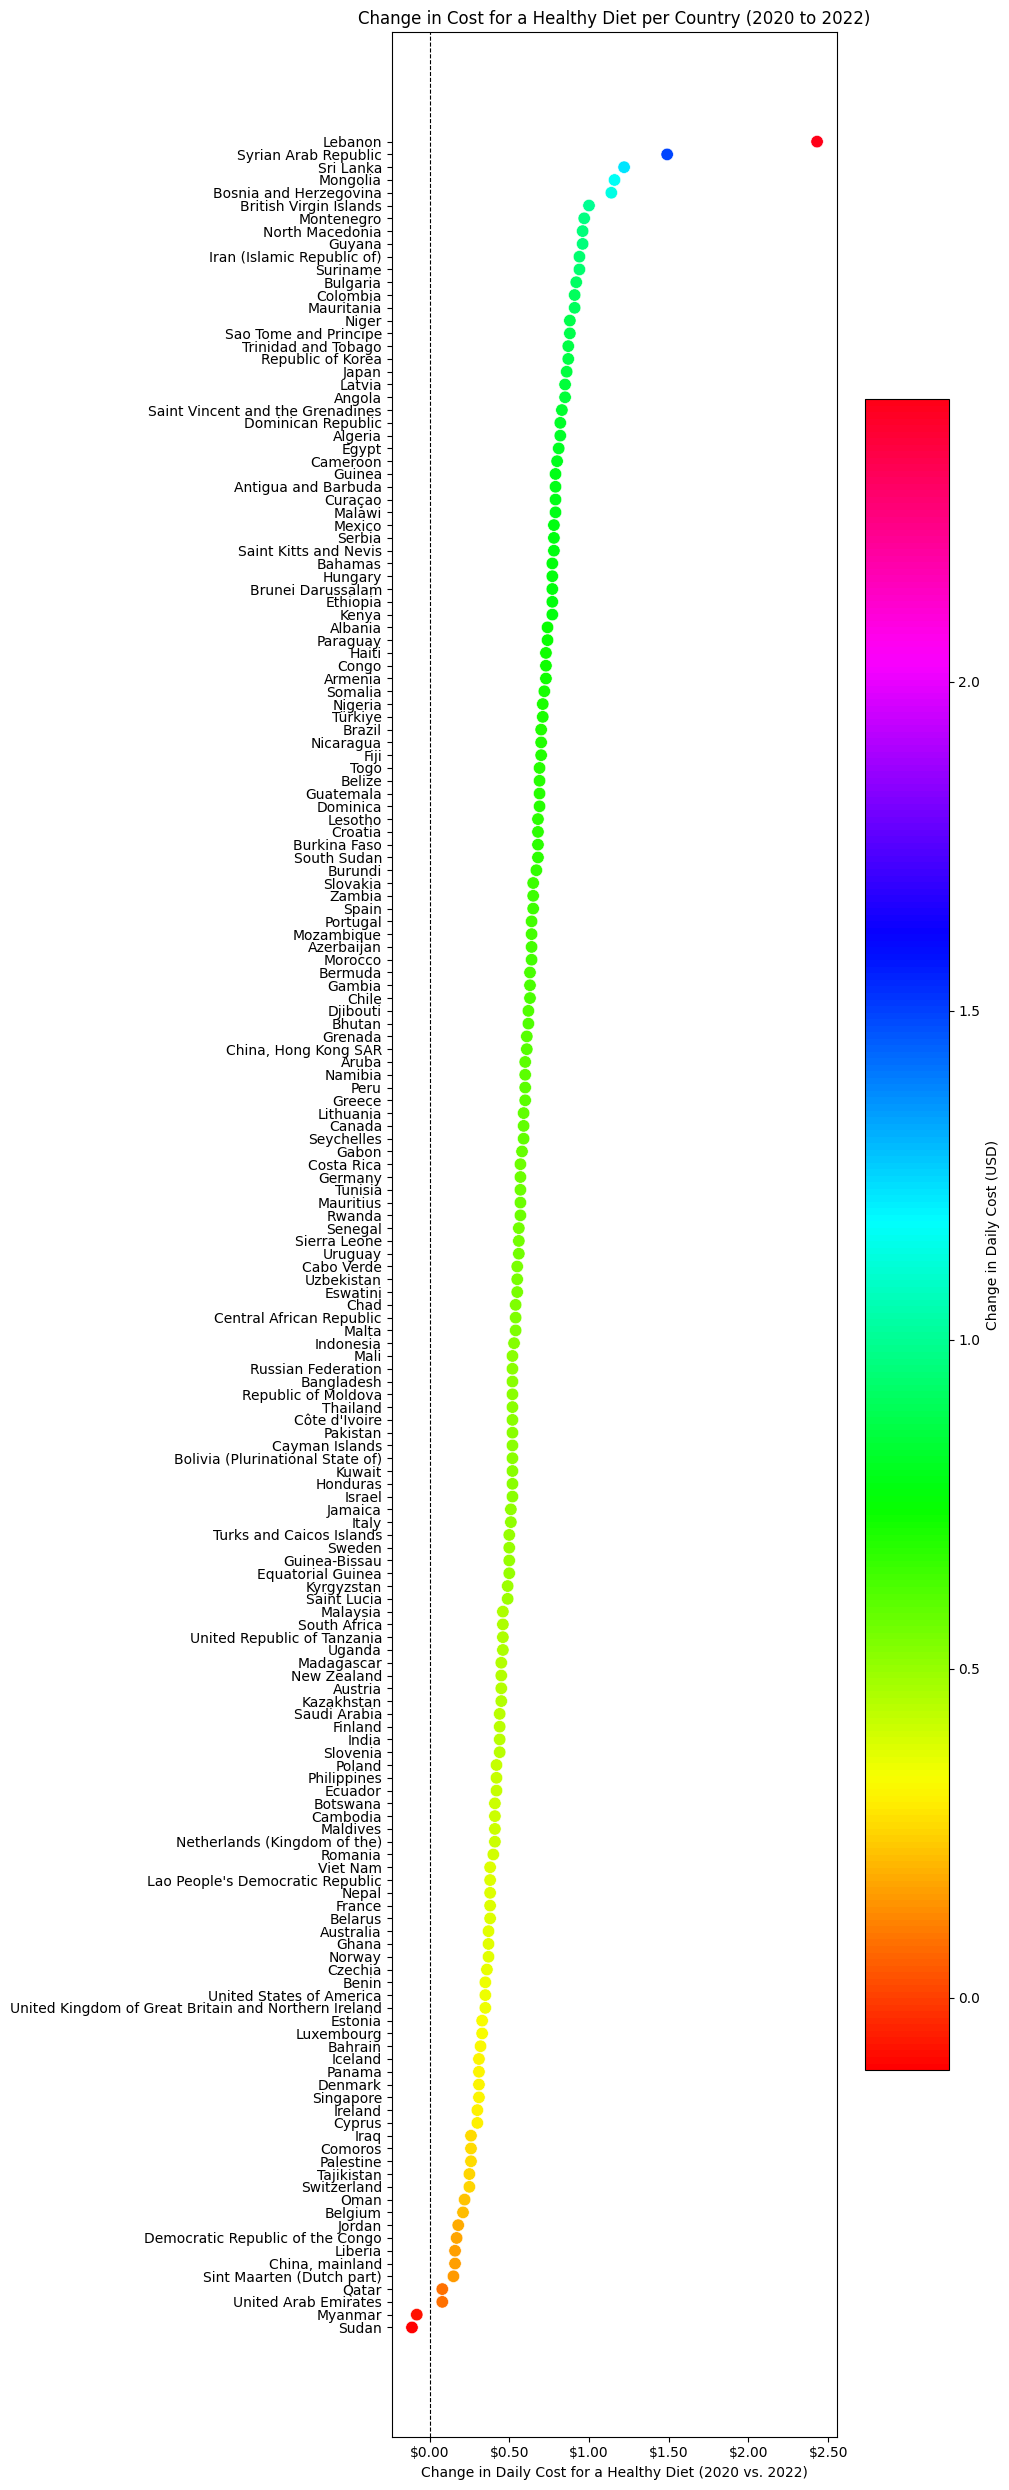

In [8]:
# Filtering to 2020 and 2020
df_2020 = df_diet[df_diet['year'] == 2020][['country_code', 'country', 'cost_healthy_diet_ppp_usd', 'annual_cost_healthy_diet_usd', 'cost_category']]
df_2022 = df_diet[df_diet['year'] == 2022][['country_code', 'country', 'cost_healthy_diet_ppp_usd', 'annual_cost_healthy_diet_usd', 'cost_category']]

# df_CC.columns()
df_CC_cols = df_CC[['name','alpha-3', 'country-code', 'region']]

# Merging it into its own DataFrame to use specifically to answer this question
df_merge_2020_2022_foods = pd.merge(df_2020, df_2022, on='country_code', suffixes=('_2020','_2022'))

# This helps to merge the DataFrames
df_merge_2020_2022_foods = pd.merge(df_merge_2020_2022_foods, df_CC_cols[['country-code', 'alpha-3', 'region']], left_on='country_code', right_on='country-code', how='left').drop(columns=['country-code'])

# This gives us a new column with the difference in daily cost of food a day
df_merge_2020_2022_foods['daily_price_change'] = (df_merge_2020_2022_foods['cost_healthy_diet_ppp_usd_2022'] - df_merge_2020_2022_foods['cost_healthy_diet_ppp_usd_2020']).round(2)

# This gives us a new column with the difference in healthy food yearly
df_merge_2020_2022_foods['yearly_price_change'] = (df_merge_2020_2022_foods['annual_cost_healthy_diet_usd_2022'] - df_merge_2020_2022_foods['annual_cost_healthy_diet_usd_2020']).round()

# This is to check the rows and columns
print(df_merge_2020_2022_foods.shape)

# This is to double check the different column names (in a list)
print(df_merge_2020_2022_foods.columns.tolist())

# This is to check first few and last few rows and columns of the DataFrame
print(df_merge_2020_2022_foods.head)

# This sorts the values in each
df_sorted_daily = df_merge_2020_2022_foods.sort_values('daily_price_change', ascending=True)
df_sorted_yearly = df_merge_2020_2022_foods.sort_values('yearly_price_change', ascending=True)

#This helps alternate the colors for the bars
rainbow = ['lightpink', 'crimson', 'seagreen', 'steelblue', 'mediumpurple', 'sandybrown', 'gold']
colors_d = [rainbow[i % len(rainbow)] for i in range(len(df_sorted_daily))]
colors_y = [rainbow[i % len(rainbow)] for i in range(len(df_sorted_yearly))]

#This is the graph for daily
fig, ax = plt.subplots(figsize=(10, 30))
ax.barh(df_sorted_daily['country_2020'], df_sorted_daily['daily_price_change'], color=colors_d, height=0.5)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Differences in Cost of Healthy Diet a Day (2020 vs. 2022)')
ax.set_title('Change in Cost of Healthy Diet a Day per Country (2020 to 2022)')
ax.set_xticklabels([f'${t:.2f}' for t in ax.get_xticks()])
plt.tight_layout()
plt.show()

#This is the graph for yearly and this is the same exact graph as the daily one so both match in data!!!
#This was used as a verification check
'''
fig, ax = plt.subplots(figsize=(10, 30))
ax.barh(df_sorted_yearly['country_2020'], df_sorted_yearly['yearly_price_change'], color=colors_y, height=0.5)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Differences in Cost of Healthy Diet (2020 vs. 2022)')
ax.set_title('Change in Cost of Healthy Diet from 2020 vs. 2022 per Country')
ax.set_xticklabels([f'${t:.2f}' for t in ax.get_xticks()])
plt.tight_layout()
plt.show()
'''

#This makes a scatterplot of the price changes
fig, ax = plt. subplots(figsize=(10, 25))
scatter = ax.scatter(
    df_sorted_daily['daily_price_change'],
    df_sorted_daily['country_2020'],
    c=df_sorted_daily['daily_price_change'],
    cmap='hsv',
    s=80,
    edgecolors='white',
    linewidth=0.4
)
plt.colorbar(scatter, ax=ax, label='Change in Daily Cost (USD)')
ax.axvline(0,color='black',linewidth=0.8,linestyle='--')
ax.set_xlabel('Change in Daily Cost for a Healthy Diet (2020 vs. 2022)')
ax.set_title('Change in Cost for a Healthy Diet per Country (2020 to 2022)')
ax.set_xticklabels([f'${t:.2f}' for t in ax.get_xticks()])
plt.tight_layout()
plt.show()



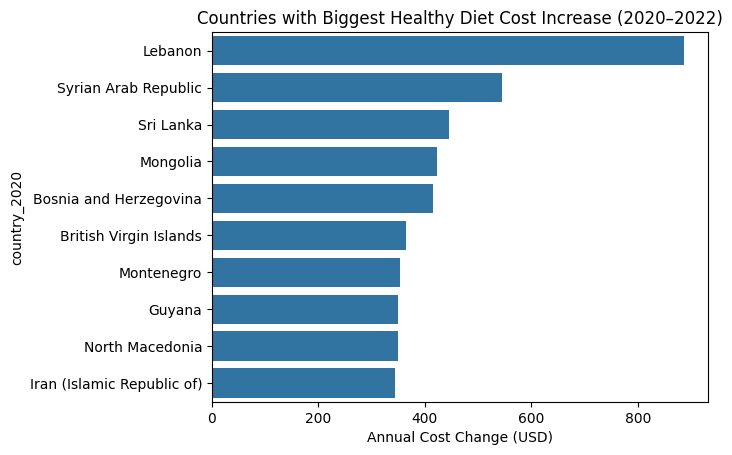

In [9]:
# Top 10 countries with biggest yearly price increase
top10 = df_merge_2020_2022_foods.nlargest(10, 'yearly_price_change')
sns.barplot(data=top10, x='yearly_price_change', y='country_2020')
plt.title('Countries with Biggest Healthy Diet Cost Increase (2020–2022)')
plt.xlabel('Annual Cost Change (USD)')
plt.show()

#This is another way we created the graph

/tmp/ipykernel_2536/2423908592.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'${t:.2f}' for t in ax.get_xticks()])


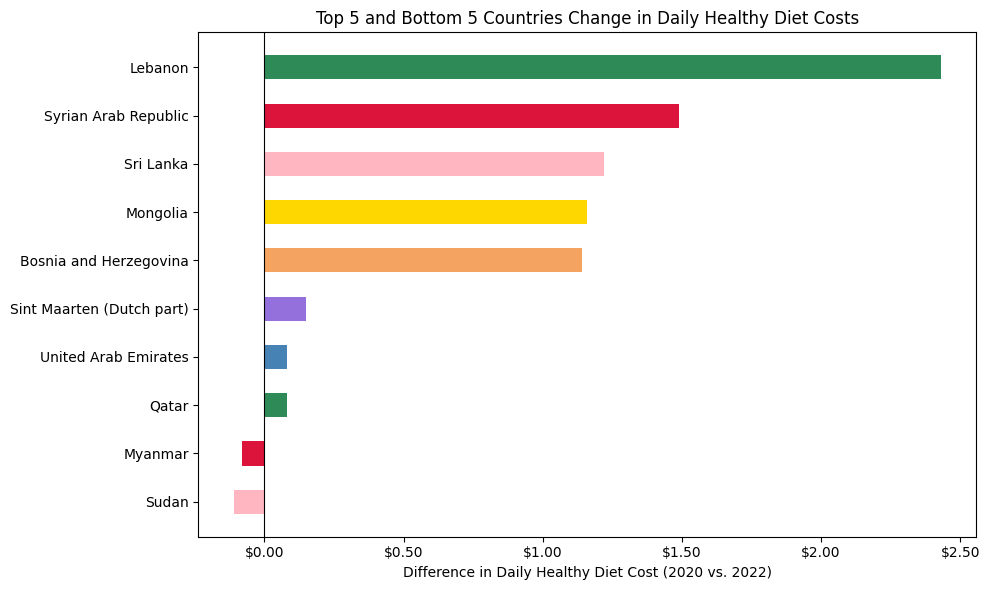

/tmp/ipykernel_2536/2423908592.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'${t:.2f}' for t in ax.get_xticks()])


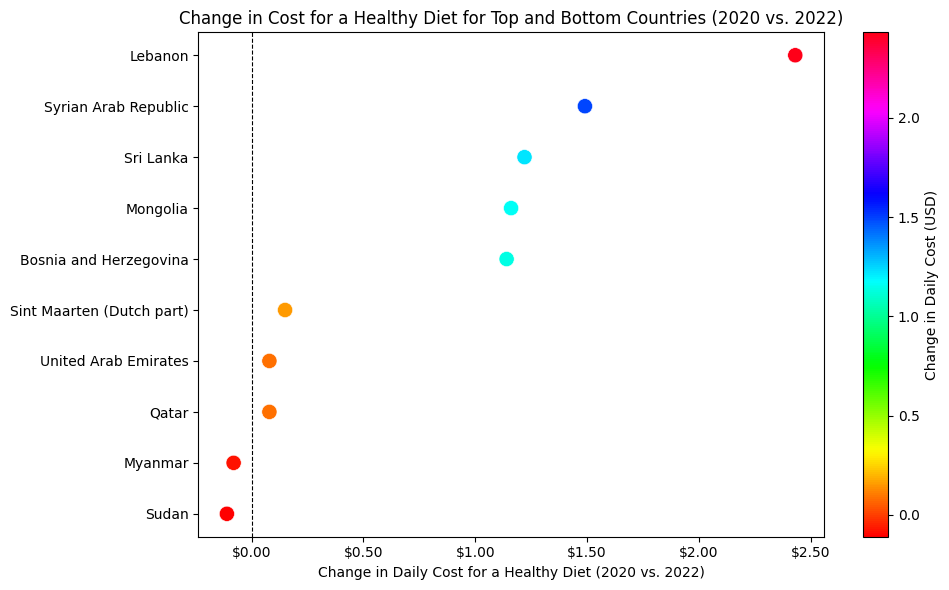

In [10]:
#This takes the top 5 countries and bottom 5 countries
top5 = df_merge_2020_2022_foods.nlargest(5, 'daily_price_change')
bottom5 = df_merge_2020_2022_foods.nsmallest(5, 'daily_price_change')
df_top_bottom = pd.concat([bottom5, top5]).sort_values('daily_price_change', ascending=True)

colors_top_bot = [rainbow[i % len(rainbow)] for i in range(len(df_top_bottom))]

#This makes the horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(df_top_bottom['country_2020'], df_top_bottom['daily_price_change'], color=colors_top_bot, height=0.5)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Difference in Daily Healthy Diet Cost (2020 vs. 2022)')
ax.set_title('Top 5 and Bottom 5 Countries Change in Daily Healthy Diet Costs')
ax.set_xticklabels([f'${t:.2f}' for t in ax.get_xticks()])
plt.tight_layout()
plt.show()

#This makes the scatter plot
fig, ax = plt. subplots(figsize=(10, 6))
scatter = ax.scatter(
    df_top_bottom['daily_price_change'],
    df_top_bottom['country_2020'],
    c=df_top_bottom['daily_price_change'],
    cmap='hsv',
    s=120,
    edgecolors='white',
    linewidth=0.4
)
plt.colorbar(scatter, ax=ax, label='Change in Daily Cost (USD)')
ax.axvline(0,color='black',linewidth=0.8,linestyle='--')
ax.set_xlabel('Change in Daily Cost for a Healthy Diet (2020 vs. 2022)')
ax.set_title('Change in Cost for a Healthy Diet for Top and Bottom Countries (2020 vs. 2022)')
ax.set_xticklabels([f'${t:.2f}' for t in ax.get_xticks()])
plt.tight_layout()
plt.show()

['cost_healthy_diet_ppp_usd_2020', 'cost_healthy_diet_ppp_usd_2022', 'annual_cost_healthy_diet_usd_2020', 'annual_cost_healthy_diet_usd_2022', 'daily_price_change', 'yearly_price_change']


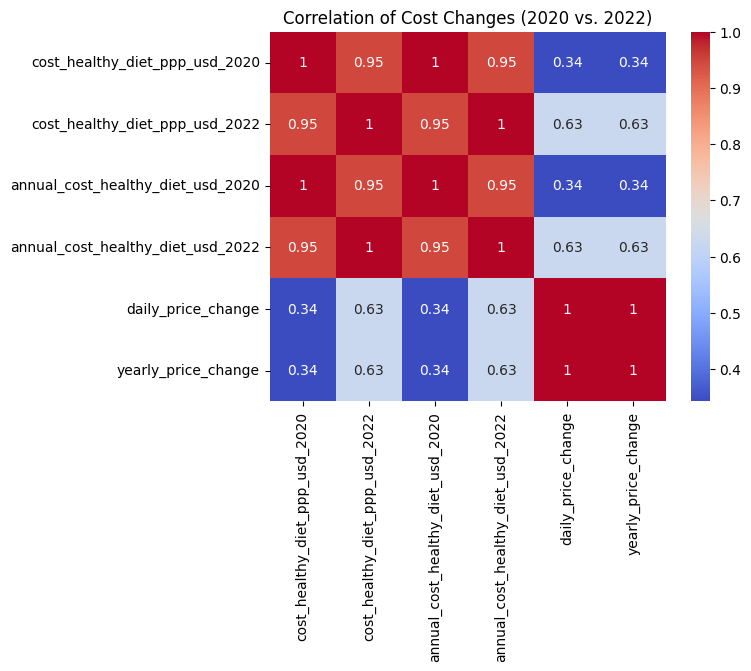

In [11]:
# I wanted to make a correlation matrix to compare each predictor to one another with a heatmap
diet_predictors = ['cost_healthy_diet_ppp_usd_2020', 'cost_healthy_diet_ppp_usd_2022', 'annual_cost_healthy_diet_usd_2020', 'annual_cost_healthy_diet_usd_2022', 'daily_price_change', 'yearly_price_change']

corr_matrix_diet = df_merge_2020_2022_foods[diet_predictors].corr()
print(diet_predictors)

sns.heatmap(corr_matrix_diet, annot=True, cmap='coolwarm')
plt.title('Correlation of Cost Changes (2020 vs. 2022)')
plt.show()
# We can easily see again that the daily and yearly costs align
# Also, we can see that there is a strong positive linear relation between the prices changes so even though there were worries about pricing due to covid, it relatively wasn't as much of a change considering
#things like inflation doing a similar think with slow price increases overtime likely.
# Additionally, it could mean that things like inflation wasn't as prevelent during the times of Covid whereas the comparison of 2020 to 2022, there is a change in price due to inflation that is natural year
#to year
#We can see though that there is a higher correlation in healthy diet costs in 2022 compared to 2020 which describes the general price increase which makes healthier food access harder in 2022 due to inflation
#With this increase in price to healthy foods, it could be making it harder for lower income familities to access nutritious foods and may take alternatives betcause of it
#This goes along back to our affordability issue and topics mentioned from Question 1 where we see which countries are affordable and which ones are not anymore
#It aligns are we can see tha Lebanon (on the map) is not as affordable between the years and a place like Sudan is still considered affordable when obtaining healthy foods.

In [12]:
# Export
df_merge_2020_2022_foods.to_csv("merged_diet_2020_2022_foods.csv", index=False)

Question 4: What may happen in the future?

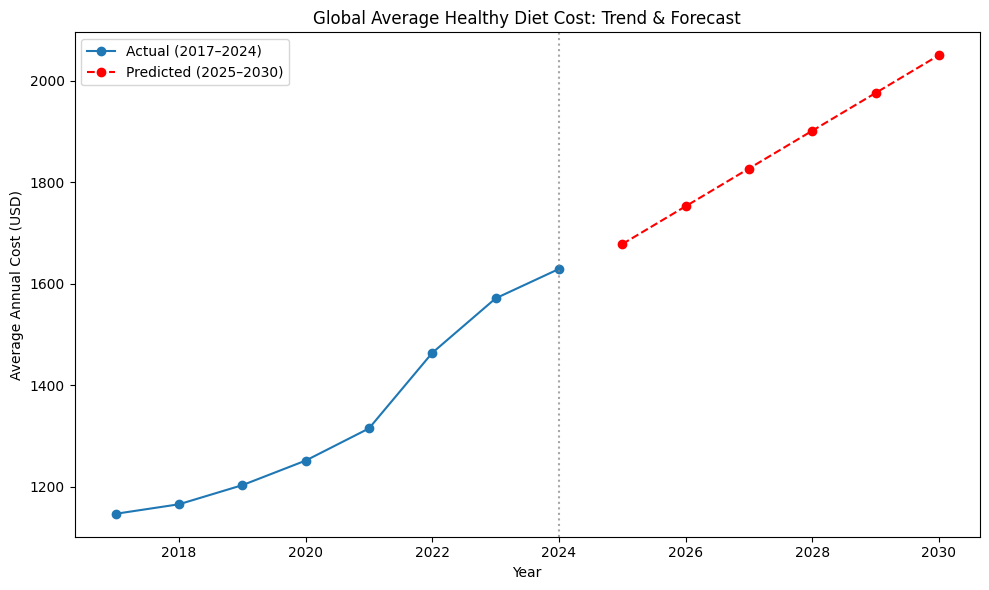

 
Predicted annual cost by 2030: $2050.35


In [13]:
# Get global average annual diet cost per year
df_trend = df_diet.groupby('year')['annual_cost_healthy_diet_usd'].mean().reset_index()

# Fit linear regression
X = df_trend[['year']]
y = df_trend['annual_cost_healthy_diet_usd']

model = LinearRegression()
model.fit(X, y)

# Predict future years from using 2025-2030 as our range
future_years = pd.DataFrame({'year': [2025, 2026, 2027, 2028, 2029, 2030]})
future_preds = model.predict(future_years)

# Combine for plotting
all_years = pd.concat([df_trend, pd.DataFrame({
    'year': future_years['year'],
    'annual_cost_healthy_diet_usd': future_preds
})])

# Plot
plt.figure(figsize=(10, 6))
plt.plot(df_trend['year'], y, marker='o', label='Actual (2017–2024)')
plt.plot(future_years['year'], future_preds, marker='o', linestyle='--', color='red', label='Predicted (2025–2030)')
plt.axvline(x=2024, color='gray', linestyle=':', alpha=0.7)
plt.title('Global Average Healthy Diet Cost: Trend & Forecast')
plt.xlabel('Year')
plt.ylabel('Average Annual Cost (USD)')
plt.legend()
plt.tight_layout()
plt.show()

print(" ")
print(f"Predicted annual cost by 2030: ${future_preds[-1]:.2f}")